<a href="https://colab.research.google.com/github/AlexanderOlivera/Analisis-de-algoritmos/blob/main/Analisis_experimental_de_complejidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análisis experimental de complejidad (Colab)

**Objetivo:** visualizar, de forma práctica, cómo cambia el tiempo de ejecución de distintos algoritmos cuando aumenta el tamaño de entrada `n`.

En este notebook trabajaremos con dos algoritmos:

1. **Búsqueda lineal (Linear Search)**  
   Recorre la lista de izquierda a derecha hasta encontrar el elemento.
   - Mejor caso: **O(1)** (si el elemento está al inicio)  
   - Peor caso: **O(n)** (si está al final o no existe)  
   - Promedio: **O(n)**

2. **BogoSort**  
   Intenta ordenar una lista **mezclándola aleatoriamente** hasta que por suerte quede ordenada.
   - Mejor caso: **O(n)** (si ya estaba ordenada; solo verifica)  
   - Caso esperado: **O(n!)** (crecimiento factorial, explota muy rápido)  
   - Peor caso: teóricamente **no acotado** (podría tardar muchísimo)

⚠️ **Nota didáctica:** BogoSort se incluye porque es muy ilustrativo: con `n` pequeño ya se vuelve impráctico.


In [ ]:
import random
import time
import math
import matplotlib.pyplot as plt


## ✅ Utilidades: generación de entradas y medición de tiempo

Para que la comparación sea más justa:
- Para cada tamaño `n` generamos **una lista nueva** (no reutilizamos la misma lista).
- Medimos tiempo con `time.perf_counter()` (más preciso para benchmarking).


In [ ]:
def generar_lista_enteros(n, low=0, high=None):
    """Genera una lista de n enteros aleatorios. Por defecto, valores en [0, n]."""
    if high is None:
        high = n
    return [random.randint(low, high) for _ in range(n)]

def medir_tiempos_por_n(func, ns, construir_args):
    """Mide el tiempo (segundos) de ejecutar func(...) para cada n en ns."""
    tiempos = []
    for n in ns:
        args, kwargs = construir_args(n)
        inicio = time.perf_counter()
        func(*args, **kwargs)
        fin = time.perf_counter()
        tiempos.append(fin - inicio)
    return tiempos


# 🔎 Algoritmo 1: Búsqueda lineal

## ¿Cómo funciona?
Dada una lista `A` y un valor `x`:
1. Se compara `x` con `A[0]`, luego con `A[1]`, etc.
2. Si se encuentra coincidencia, se retorna el índice.
3. Si termina el recorrido sin encontrarlo, se retorna `-1`.

En el peor caso se hacen **n comparaciones** → **O(n)**.


In [ ]:
def busqueda_lineal(lista, x):
    for i in range(len(lista)):
        if lista[i] == x:
            return i
    return -1


## Experimento: tiempo vs tamaño de entrada

Haremos dos escenarios para apreciar diferencias:

- **Mejor caso:** buscar un elemento que está al inicio.
- **Peor caso:** buscar un elemento que está al final.

Esto permite ver que el rendimiento también depende del **caso** (best/worst).


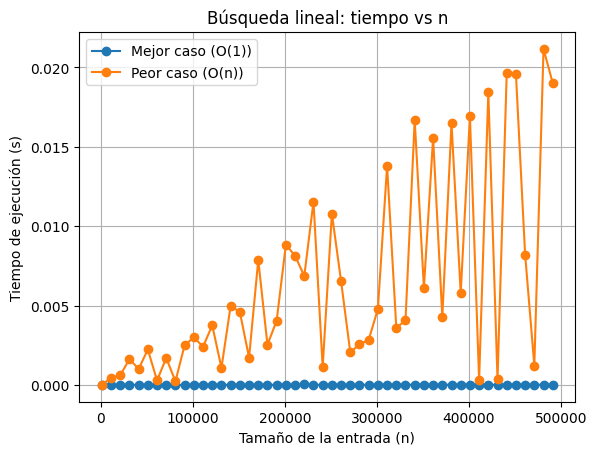

In [ ]:
# Tamaños de entrada para búsqueda lineal
ns_lineal = list(range(1_000, 500_001, 10_000))

def args_mejor_caso(n):
    A = generar_lista_enteros(n)
    x = A[0]  # al inicio
    return (A, x), {}

def args_peor_caso(n):
    A = generar_lista_enteros(n)
    x = A[-1]  # al final
    return (A, x), {}

tiempos_lineal_mejor = medir_tiempos_por_n(busqueda_lineal, ns_lineal, args_mejor_caso)
tiempos_lineal_peor  = medir_tiempos_por_n(busqueda_lineal, ns_lineal, args_peor_caso)

plt.figure()
plt.plot(ns_lineal, tiempos_lineal_mejor, marker="o", label="Mejor caso (O(1))")
plt.plot(ns_lineal, tiempos_lineal_peor,  marker="o", label="Peor caso (O(n))")
plt.xlabel("Tamaño de la entrada (n)")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Búsqueda lineal: tiempo vs n")
plt.grid(True)
plt.legend()
plt.show()


✅ **Qué esperar:**  
- La curva del **mejor caso** debería ser casi plana.  
- La curva del **peor caso** debería crecer aproximadamente de forma lineal.


# 🎲 Algoritmo 2: BogoSort

## ¿Cómo funciona?
1. Revisa si la lista está ordenada.
2. Si no, la **mezcla aleatoriamente**.
3. Repite hasta que por azar quede ordenada.

## ¿Por qué es tan lento?
Para tamaño `n` hay `n!` permutaciones posibles. En promedio, necesitarías intentar un número proporcional a `n!` mezclas para caer en la permutación ordenada.

Por eso su crecimiento es **factorial**.


In [ ]:
def isOrdered(A):
    # Verifica si A está ordenada de forma no-decreciente
    for i in range(1, len(A)):
        if A[i-1] > A[i]:
            return False
    return True

def bogoSort(A, max_shuffles=250_000):
    """BogoSort con límite de mezclas para evitar ejecuciones interminables."""
    shuffles = 0
    while not isOrdered(A):
        random.shuffle(A)
        shuffles += 1
        if shuffles >= max_shuffles:
            return A, shuffles, False  # no se logró dentro del límite
    return A, shuffles, True


## Experimento: tiempo vs tamaño de entrada

Como BogoSort puede tardar muchísimo, usaremos:
- tamaños pequeños `n = 1..12`,
- un **límite de mezclas** `max_shuffles`,
- y repetiremos varias veces por cada `n` (promedio) para reducir el ruido.


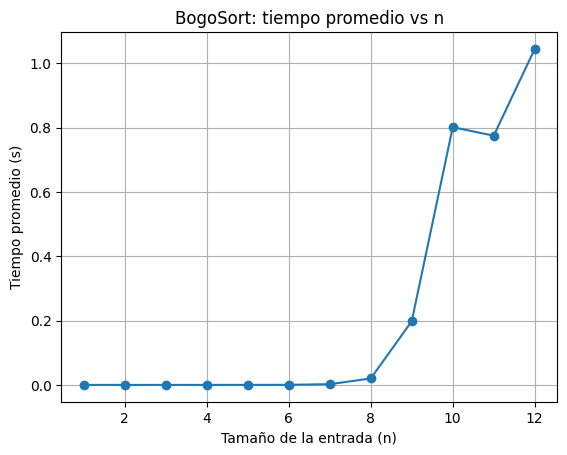

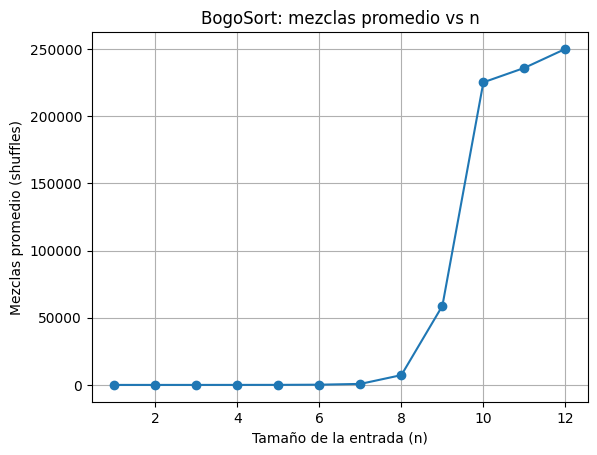

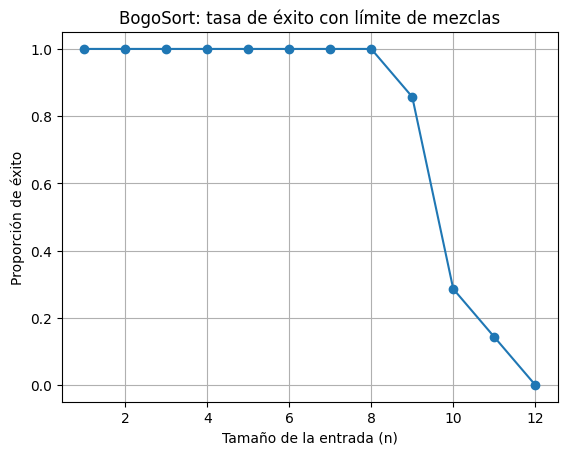

In [ ]:
def medir_bogosort_promedio(ns, repeticiones=7, max_shuffles=250_000):
    tiempos_promedio = []
    mezclas_promedio = []
    exito_por_n = []

    for n in ns:
        tiempos = []
        mezclas = []
        exitos = 0

        for _ in range(repeticiones):
            A = generar_lista_enteros(n)
            inicio = time.perf_counter()
            _, sh, ok = bogoSort(A, max_shuffles=max_shuffles)
            fin = time.perf_counter()

            tiempos.append(fin - inicio)
            mezclas.append(sh)
            if ok:
                exitos += 1

        tiempos_promedio.append(sum(tiempos) / repeticiones)
        mezclas_promedio.append(sum(mezclas) / repeticiones)
        exito_por_n.append(exitos / repeticiones)

    return tiempos_promedio, mezclas_promedio, exito_por_n

ns_bogo = list(range(1, 13))  # 1..12
tiempos_bogo, mezclas_bogo, exito_bogo = medir_bogosort_promedio(ns_bogo)

plt.figure()
plt.plot(ns_bogo, tiempos_bogo, marker="o")
plt.xlabel("Tamaño de la entrada (n)")
plt.ylabel("Tiempo promedio (s)")
plt.title("BogoSort: tiempo promedio vs n")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(ns_bogo, mezclas_bogo, marker="o")
plt.xlabel("Tamaño de la entrada (n)")
plt.ylabel("Mezclas promedio (shuffles)")
plt.title("BogoSort: mezclas promedio vs n")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(ns_bogo, exito_bogo, marker="o")
plt.xlabel("Tamaño de la entrada (n)")
plt.ylabel("Proporción de éxito")
plt.title("BogoSort: tasa de éxito con límite de mezclas")
plt.grid(True)
plt.show()


✅ **Qué esperar:**  
- Tiempo y número de mezclas crecen **rapidísimo**.  
- Para `n` más grandes, puede bajar la tasa de éxito si el límite de mezclas no alcanza.


# 🧠 Comparación cualitativa final (escala log)

Como las escalas son muy diferentes, usamos **escala logarítmica** en el eje Y para comparar tendencias.


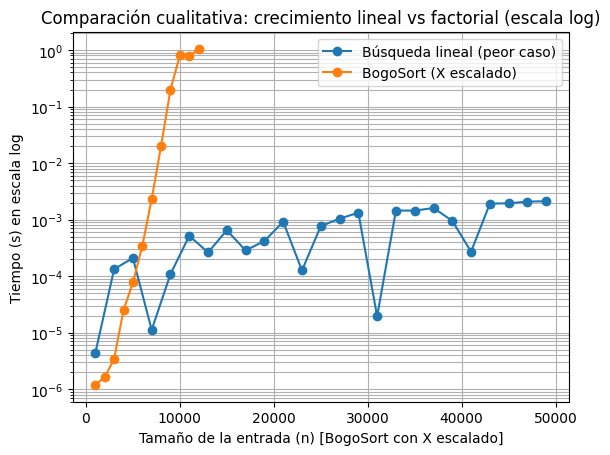

In [ ]:
# Comparamos de forma cualitativa:
# - búsqueda lineal (peor caso) con n más grande
# - BogoSort con n pequeño
# Para visualizar en una misma figura, escalamos el eje X de BogoSort (solo para comparación visual).
ns_comp = list(range(1_000, 50_001, 2_000))

def args_peor_caso_comp(n):
    A = generar_lista_enteros(n)
    x = A[-1]
    return (A, x), {}

tiempos_lineal_peor_comp = medir_tiempos_por_n(busqueda_lineal, ns_comp, args_peor_caso_comp)

plt.figure()
plt.plot(ns_comp, tiempos_lineal_peor_comp, marker="o", label="Búsqueda lineal (peor caso)")

# Escalamos X para que no quede pegado en el origen (solo visual)
x_bogo_escalado = [n * 1000 for n in ns_bogo]
plt.plot(x_bogo_escalado, tiempos_bogo, marker="o", label="BogoSort (X escalado)")

plt.yscale("log")
plt.xlabel("Tamaño de la entrada (n) [BogoSort con X escalado]")
plt.ylabel("Tiempo (s) en escala log")
plt.title("Comparación cualitativa: crecimiento lineal vs factorial (escala log)")
plt.grid(True, which="both")
plt.legend()
plt.show()


# ✅ Preguntas para que respondan (cierre)

1. ¿Cuál algoritmo “aguanta” tamaños grandes y por qué?
2. ¿Qué significa que BogoSort tenga crecimiento factorial?
3. ¿Por qué el mejor caso de búsqueda lineal se ve casi constante?
4. ¿Qué ajuste harías al experimento para medir mejor el *caso promedio*?
5. Si tuvieras que ordenar una lista grande, ¿por qué BogoSort no es opción?
